# Chapter 27 Lab — Experimental Design and Task fMRI (Python)

In this lab you will score fMRI designs *before collecting any data*. We follow a four-step arc:

1. **Build the machinery**: a canonical HRF and a design-matrix builder that turns event onsets into predicted BOLD regressors
2. **Score competing designs**: compute the efficiency of an A − B contrast for a blocked design, a dense fixed-ISI event-related design, and a sparse jittered event-related design
3. **Diagnose collinearity** with variance inflation factors (VIFs)
4. **Map the detection–estimation tradeoff**: score many designs under both a canonical-HRF model (contrast detection) and a flexible FIR model (HRF shape estimation)

Everything here uses simulated timing only — no scanner data required — which is exactly the point: efficiency depends purely on the design matrix, so you can (and should) evaluate designs before the study is run.

**How to run this notebook.** Run it in your browser from the tutorial site, in Google Colab, or in a local Jupyter environment with numpy, scipy, and matplotlib installed. See the [chapter page](../ch27-experimental-design-and-task-fmri.md) for the concepts behind each step.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(27)
np.set_printoptions(precision=3, suppress=True)
print("numpy", np.__version__)

numpy 2.4.6


## Step 1 — The machinery: HRF and design builder

Task predictors are built by convolving a **stimulus indicator function** (1 during hypothesized neural activity, 0 elsewhere) with a **canonical HRF** (Chapter 18). All designs in this lab share:

- run length $T = 480$ s, sampled at 1 s (480 "volumes")
- two event types, **A** and **B**, each lasting 2 s
- event *slots* every 4 s (the minimum ISI); designs differ only in how slots are filled

The helper below returns a design matrix with columns [A, B, intercept].

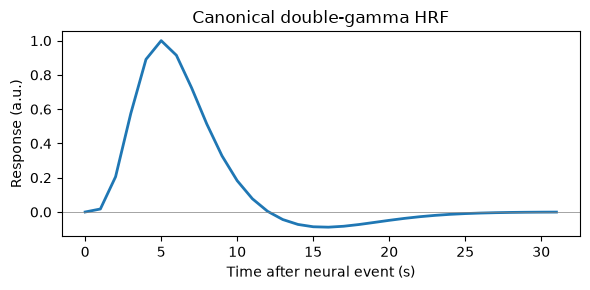

In [2]:
T = 480                     # run length (s)
dt = 1.0                    # sampling resolution (s); think TR = 1
t = np.arange(0, T, dt)
slots = np.arange(0, T, 4.0)          # candidate event onsets, every 4 s

def canonical_hrf(tt):
    # Double-gamma canonical HRF (SPM-style parameters), peak-normalized
    h = stats.gamma.pdf(tt, 6, scale=1) - stats.gamma.pdf(tt, 16, scale=1) / 6
    return h / h.max()

hrf = canonical_hrf(np.arange(0, 32, dt))

def stimulus(onsets, dur=2.0):
    # Indicator function: 1 during events, 0 elsewhere
    s = np.zeros_like(t)
    for on in onsets:
        s[(t >= on) & (t < on + dur)] = 1.0
    return s

def design(onsets_A, onsets_B, dur=2.0):
    # Convolve each condition's indicator with the HRF; intercept last
    X = np.ones((len(t), 3))
    X[:, 0] = np.convolve(stimulus(onsets_A, dur), hrf)[:len(t)]
    X[:, 1] = np.convolve(stimulus(onsets_B, dur), hrf)[:len(t)]
    return X

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(np.arange(0, 32, dt), hrf, lw=2)
ax.axhline(0, color="gray", lw=0.5)
ax.set(xlabel="Time after neural event (s)", ylabel="Response (a.u.)",
       title="Canonical double-gamma HRF")
plt.tight_layout()

## Step 2 — Three competing designs

We now fill the event slots three different ways, holding run length and conditions constant:

- **Blocked**: 16-s blocks of A alternate with 16-s blocks of B (events presented back-to-back within each block, the classic A–B–A–B arrangement)
- **Dense fixed-ISI event-related**: every slot holds an event, order randomized (60 A + 60 B, no rest)
- **Sparse jittered event-related**: each slot is A, B, or *rest* with equal probability — the rest slots create variable, "jittered" inter-trial intervals

These are exactly the three arrangements in Figure 27.1 of the book.

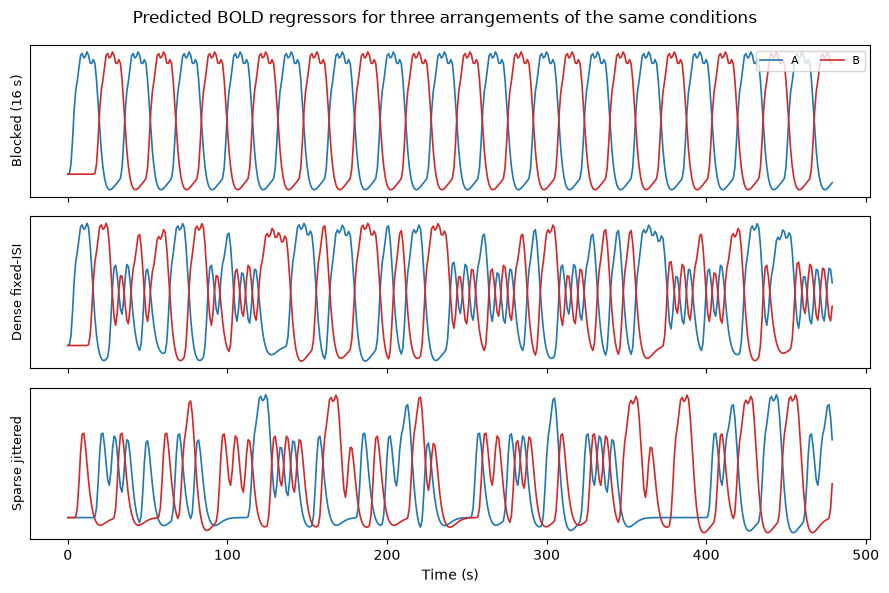

In [3]:
# --- Blocked: alternating 16-s blocks (4 consecutive slots per block) ---
block_lab = np.tile(np.repeat([0, 1], 4), len(slots) // 8)   # AAAABBBB...
ons_block = (slots[block_lab == 0], slots[block_lab == 1])

# --- Dense fixed-ISI ER: every slot filled, random order, 50/50 A/B ---
dense_lab = rng.permutation(np.repeat([0, 1], len(slots) // 2))
ons_dense = (slots[dense_lab == 0], slots[dense_lab == 1])

# --- Sparse jittered ER: slots are A, B, or rest (1/3 each) ---
sparse_lab = rng.choice([0, 1, 2], size=len(slots), p=[1/3, 1/3, 1/3])
ons_sparse = (slots[sparse_lab == 0], slots[sparse_lab == 1])

designs = {
    "Blocked (16 s)":  design(*ons_block),
    "Dense fixed-ISI": design(*ons_dense),
    "Sparse jittered": design(*ons_sparse),
}

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for ax, (name, X) in zip(axes, designs.items()):
    ax.plot(t, X[:, 0], color="tab:blue", lw=1.2, label="A")
    ax.plot(t, X[:, 1], color="tab:red", lw=1.2, label="B")
    ax.set_ylabel(name, fontsize=9)
    ax.set_yticks([])
axes[0].legend(loc="upper right", ncol=2, fontsize=8)
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Predicted BOLD regressors for three arrangements of the same conditions")
plt.tight_layout()

Note the qualitative differences: the blocked regressors swing slowly between high and low values (high variance, and A is high exactly when B is low); the dense regressors wiggle rapidly around a high plateau; the sparse regressors rise and fall as jitter lets the signal return toward baseline.

### Score each design's efficiency

The design-related variance of a contrast $c$ is $c\,(X^TX)^{-1}c^T$, and efficiency is its inverse:

$$ e_c = \frac{1}{c\,(X^TX)^{-1}\,c^T} $$

We score two questions each design might be asked to answer:

- **A − B**: which regions respond differently to the two conditions? ($c = [1, -1, 0]$)
- **A vs. baseline**: which regions respond to A at all, relative to unmodeled rest? ($c = [1, 0, 0]$)

design              e(A - B)  e(A vs baseline)
Blocked (16 s)         750.9              22.2
Dense fixed-ISI        449.5              22.1
Sparse jittered        268.3             306.5


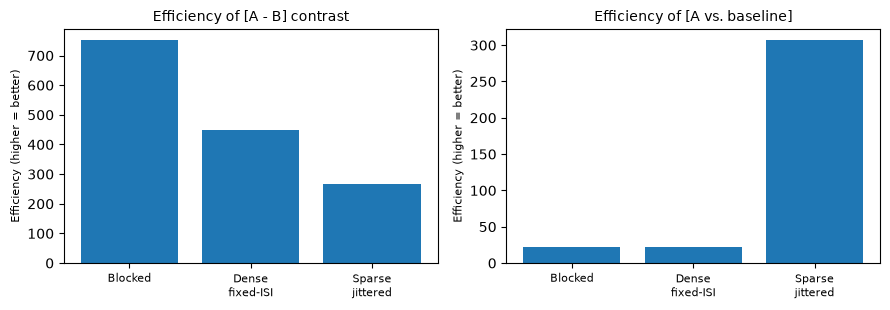

In [4]:
def contrast_efficiency(X, c):
    c = np.asarray(c, float)
    return 1.0 / (c @ np.linalg.pinv(X.T @ X) @ c)

c_diff = [1, -1, 0]      # A - B
c_base = [1, 0, 0]       # A vs. implicit baseline

print(f"{'design':<18}{'e(A - B)':>10}{'e(A vs baseline)':>18}")
for name, X in designs.items():
    print(f"{name:<18}{contrast_efficiency(X, c_diff):>10.1f}"
          f"{contrast_efficiency(X, c_base):>18.1f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, c, title in [(axes[0], c_diff, "Efficiency of [A - B] contrast"),
                     (axes[1], c_base, "Efficiency of [A vs. baseline]")]:
    vals = [contrast_efficiency(X, c) for X in designs.values()]
    ax.bar(range(3), vals, color="tab:blue")
    ax.set_xticks(range(3))
    ax.set_xticklabels(["Blocked", "Dense\nfixed-ISI", "Sparse\njittered"], fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Efficiency (higher = better)", fontsize=8)
plt.tight_layout()

**Interpretation.** For the A − B contrast, the blocked design wins by a large margin — it concentrates the predicted A − B difference at a slow frequency with maximal variance, reproducing Figure 27.1B. The dense design does reasonably (randomized order still creates A − B variance), and the sparse design is least efficient because much of its time is spent at rest.

The picture changes for **A vs. baseline**. In the dense design, events occur constantly, so the A regressor hovers near a plateau and is partly confounded with the intercept — there is little "baseline" left to compare against. Jitter is what buys you peaks *and valleys* specific to each condition, so the sparse design holds its own for baseline comparisons despite having fewer trials. This is the core lesson: **which design is best depends on which contrast you care about**, and you should score the contrasts you actually plan to test.

## Step 3 — Collinearity and variance inflation factors

Efficiency suffers when regressors are correlated — the model cannot decide which predictor deserves credit. Pairwise correlations miss the worst case, where one regressor is predictable from a *combination* of others, so the standard diagnostic is the **variance inflation factor**:

$$ \mathrm{VIF}_j = \frac{1}{1 - R_j^2} $$

where $R_j^2$ comes from regressing predictor $j$ on all the other predictors. VIF = 1 is perfect (orthogonal); ~2+ deserves attention; ~4–8+ is serious trouble.

To see VIFs blow up, we corrupt the dense design: three quarters of B's onsets are moved onto A's onsets, so the two event types usually co-occur — as if two "different" conditions were almost always presented together.

In [5]:
def vif(X):
    """VIF for each non-intercept column of X."""
    Xc = X[:, :-1] - X[:, :-1].mean(axis=0)   # drop intercept, center
    out = []
    for j in range(Xc.shape[1]):
        yj, Xo = Xc[:, j], np.delete(Xc, j, axis=1)
        b, *_ = np.linalg.lstsq(Xo, yj, rcond=None)
        r2 = 1 - np.sum((yj - Xo @ b) ** 2) / np.sum(yj ** 2)
        out.append(1.0 / (1.0 - r2))
    return np.array(out)

# Corrupt the dense design: move 75% of B's onsets onto A's onsets
onsA, onsB = ons_dense[0], ons_dense[1].copy()
n_move = int(0.75 * len(onsB))
onsB[:n_move] = onsA[:n_move]
X_coll = design(onsA, np.unique(onsB))

for name, X in [("dense random", designs["Dense fixed-ISI"]),
                ("collinear", X_coll)]:
    v = vif(X)
    r = np.corrcoef(X[:, 0], X[:, 1])[0, 1]
    print(f"{name:<14} corr(A,B) = {r:5.2f}   VIF_A = {v[0]:6.2f}   VIF_B = {v[1]:6.2f}")

dense random   corr(A,B) = -0.98   VIF_A =  20.61   VIF_B =  20.61
collinear      corr(A,B) =  0.63   VIF_A =   1.68   VIF_B =   1.68


In the randomized design the VIFs sit near 1 — this is the payoff of *designing* an experiment rather than observing correlated variables in the world. In the corrupted design, both task regressors have high VIFs: each is largely predictable from the other, so each $\hat{\beta}$'s variance is inflated several-fold, and the two estimates become (negatively) correlated — true signal for A can masquerade as deactivation for B.

Note that high VIFs do not always doom a study: even when individual betas are poorly estimable, some *contrasts* may still be fine. The classic example is a no-rest design where A and B are each confounded with baseline (huge VIFs vs. the intercept) but A − B is estimated precisely.

## Step 4 — The detection–estimation tradeoff

So far we assumed the canonical HRF is correct and asked how well designs *detect* contrasts. The complementary question is how well a design lets you *estimate the shape* of the response, using a **finite impulse response (FIR)** model with one free parameter per post-stimulus time point (here, 16 lags of 1 s per condition).

Both questions use the same efficiency formula with different design matrices:

- **Detection efficiency**: $e_c$ for the A − B contrast under the canonical-HRF model
- **Estimation efficiency**: $e = p \, / \, \mathrm{trace}[(X^TX)^{-1}]$ over the $p$ FIR parameters

We score many random designs that vary in their proportion of rest (jitter), plus the blocked design, on both criteria — a home-made version of Figure 27.4 in the book.

Blocked design:  detection = 750.9,  estimation = 0.679
Best random ER:  detection = 521.5,  estimation = 22.582


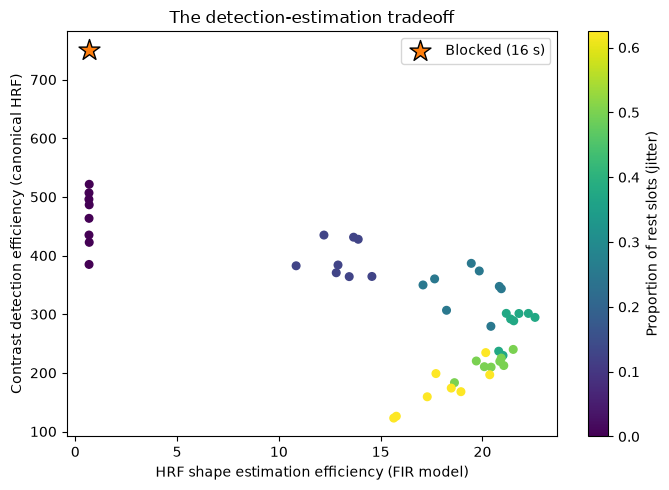

In [6]:
FIR_LAGS = 16      # estimate response at lags 0..15 s after onset

def fir_design(onsets_A, onsets_B):
    # One shifted-stick-function column per lag per condition; intercept last
    X = np.ones((len(t), 2 * FIR_LAGS + 1))
    for jcond, onsets in enumerate([onsets_A, onsets_B]):
        stick = np.zeros(len(t))
        stick[np.round(np.asarray(onsets) / dt).astype(int)] = 1.0
        for lag in range(FIR_LAGS):
            X[:, jcond * FIR_LAGS + lag] = np.roll(stick, lag)
            X[lag > np.arange(len(t)), jcond * FIR_LAGS + lag] = 0  # no wraparound
    return X

def estimation_efficiency(onsets_A, onsets_B):
    Xf = fir_design(onsets_A, onsets_B)
    v = np.diag(np.linalg.pinv(Xf.T @ Xf))[:-1]     # FIR columns only
    return (2 * FIR_LAGS) / v.sum()

def detection_efficiency(onsets_A, onsets_B):
    return contrast_efficiency(design(onsets_A, onsets_B), [1, -1, 0])

# Random event-related designs with varying amounts of rest (jitter)
rest_props = [0.0, 0.125, 0.25, 0.375, 0.5, 0.625]
det, est, col = [], [], []
for p_rest in rest_props:
    for _ in range(8):
        p_ev = (1 - p_rest) / 2
        lab = rng.choice([0, 1, 2], size=len(slots), p=[p_ev, p_ev, p_rest])
        oA, oB = slots[lab == 0], slots[lab == 1]
        det.append(detection_efficiency(oA, oB))
        est.append(estimation_efficiency(oA, oB))
        col.append(p_rest)

det_block = detection_efficiency(*ons_block)
est_block = estimation_efficiency(*ons_block)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(est, det, c=col, cmap="viridis", s=30)
ax.scatter([est_block], [det_block], marker="*", s=250, color="tab:orange",
           edgecolor="k", zorder=5, label="Blocked (16 s)")
ax.set(xlabel="HRF shape estimation efficiency (FIR model)",
       ylabel="Contrast detection efficiency (canonical HRF)",
       title="The detection-estimation tradeoff")
fig.colorbar(sc, label="Proportion of rest slots (jitter)")
ax.legend(loc="upper right")
plt.tight_layout()

print(f"Blocked design:  detection = {det_block:.1f},  estimation = {est_block:.3f}")
print(f"Best random ER:  detection = {max(det):.1f},  estimation = {max(est):.3f}")

**Interpretation.** The blocked design (star) sits far up the detection axis but far left on estimation: its events are packed into predictable runs, so the shifted FIR sticks are nearly collinear and the response shape is almost unrecoverable. Random event-related designs form a cloud: adding jitter (lighter points) improves shape estimation — the varied spacing decorrelates the FIR columns — while trading away some detection efficiency. No design in the cloud dominates both axes: this is the tradeoff of Figure 27.4.

Where the book's figure goes further is the frontier: **m-sequences** (pseudorandom sequences orthogonal to their own time-shifted copies) reach the estimation extreme, and **genetic algorithms** — which recombine pieces of the best designs across "generations," using a fitness function that weights the contrasts and models you actually care about — find designs that beat random search on *both* axes and approach the theoretical limit. The CANlab `OptimizeDesign` toolbox (`optimizeGA.m`) implements such a GA for MATLAB, and the companion MATLAB live script for this chapter shows how to set one up.

## Wrap-up and exercises

You scored designs before any data were collected using only $X$: blocked designs win for contrast detection, jitter buys baseline comparisons and HRF estimation, VIFs flag collinearity, and detection versus estimation is a genuine tradeoff that optimization algorithms can navigate.

**Try on your own:**

1. Re-run Step 2 with 8-s and 32-s blocks. Where does the A − B efficiency peak, and why might very long blocks be risky in real data (hint: high-pass filters)?
2. In Step 4, add a *fixed* 4-s ISI, strictly alternating design (ABABAB...). Where does it land on the tradeoff plot, and why is its A − B detection efficiency so poor? (Hint: what temporal frequency does the A − B difference oscillate at, and what does the HRF do to high frequencies?)
3. Modify the efficiency scoring to include a high-pass filter: residualize the columns of $X$ against a discrete cosine basis (periods > 128 s) before computing $e$. How much does the 16-s blocked design lose? What happens with 64-s blocks?
4. Write a mini-optimizer: generate 500 random designs at 30% rest and keep the one with the best *weighted sum* of detection and estimation efficiency (z-score each first). How much does the winner beat the average by?
